### importing chronos package on student cluster

In [25]:
%pip install -t ./my_packages chronos-forecasting

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 10.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.6/65.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 67.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 87.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 10.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 13.5 MB/s eta 0:00:0000:0100:0

## importing all needed packages

In [8]:
import sys
import os

# 1. Point Python to your custom packages folder
sys.path.insert(0, os.path.abspath('./my_packages'))

# 2. Now you can import everything normally!
import pandas as pd
import numpy as np
import torch
from chronos import ChronosPipeline
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from itertools import product
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score
import torch
import copy
import random
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Question 4.2

Use an LLM to create embeddings. These embeddings can be used to train a linear probe.

In [6]:
#Load data

df_train = pd.read_parquet("set_a.parquet")
df_val   = pd.read_parquet("set_b.parquet")
df_test  = pd.read_parquet("set_c.parquet")

#note same function as in Exercise 2.1 to get the simple extracted features
DYNAMIC_VARS = sorted([
    'ALP', 'ALT', 'AST', 'Albumin', 'BUN', 'Bilirubin', 'Cholesterol',
    'Creatinine', 'DiasABP', 'FiO2', 'GCS', 'Glucose', 'HCO3', 'HCT',
    'HR', 'K', 'Lactate', 'MAP', 'MechVent', 'Mg', 'NIDiasABP', 'NIMAP',
    'NISysABP', 'Na', 'PaCO2', 'PaO2', 'Platelets', 'RespRate', 'SaO2',
    'SysABP', 'Temp', 'TroponinI', 'TroponinT', 'Urine', 'WBC', 'Weight', 'pH'
])
STATIC_VARS = ['Age', 'Gender', 'Height', 'StaticWeight']
ALL_FEATURES = DYNAMIC_VARS + STATIC_VARS  # 41 features total

def extract_simple_features(df):
    """
    Per patient:
      - Forward-fill measurements over time to ignore gaps/NaNs.
      - Dynamic variables: take the last non-null value after ffill.
      - Static variables: take as-is (they are constant).
    Returns one row per patient with features + label.
    """
    df_sorted = df.sort_values(["RecordID", "hour"])
    
    # Forward-fill all columns within each patient group
    df_filled = df_sorted.groupby("RecordID").ffill()
    
    # groupby.ffill() drops the grouping key, so we map it back from the sorted dataframe
    df_filled["RecordID"] = df_sorted["RecordID"] 
    
    # Drop duplicates to keep only the final chronological row per patient
    last_row = df_filled.drop_duplicates(subset=["RecordID"], keep="last")

    features = last_row[["RecordID"] + ALL_FEATURES].copy()
    labels   = last_row[["RecordID", "In-hospital_death"]].copy()
    
    return features, labels

X_train, y_train = extract_simple_features(df_train)
X_val,   y_val   = extract_simple_features(df_val)
X_test,  y_test  = extract_simple_features(df_test)


### dictionaries for transfering knowledge to LLM

In [7]:
# Short-name to full-name and unit mappings for all available variables
FEATURE_FULL_NAMES = {
    "RecordID": "ICU stay identifier",
    "hour": "Hours since ICU admission",
    "ALP": "Alkaline phosphatase",
    "ALT": "Alanine transaminase",
    "AST": "Aspartate transaminase",
    "Albumin": "Serum albumin",
    "BUN": "Blood urea nitrogen",
    "Bilirubin": "Total bilirubin",
    "Cholesterol": "Total cholesterol",
    "Creatinine": "Serum creatinine",
    "DiasABP": "Invasive diastolic arterial blood pressure",
    "FiO2": "Fraction of inspired oxygen",
    "GCS": "Glasgow Coma Score",
    "Glucose": "Serum glucose",
    "HCO3": "Serum bicarbonate",
    "HCT": "Hematocrit",
    "HR": "Heart rate",
    "K": "Serum potassium",
    "Lactate": "Serum lactate",
    "MAP": "Invasive mean arterial blood pressure",
    "MechVent": "Mechanical ventilation flag",
    "Mg": "Serum magnesium",
    "NIDiasABP": "Non-invasive diastolic arterial blood pressure",
    "NIMAP": "Non-invasive mean arterial blood pressure",
    "NISysABP": "Non-invasive systolic arterial blood pressure",
    "Na": "Serum sodium",
    "PaCO2": "Partial pressure of arterial CO2",
    "PaO2": "Partial pressure of arterial O2",
    "Platelets": "Platelet count",
    "RespRate": "Respiration rate",
    "SaO2": "Oxygen saturation of hemoglobin",
    "SysABP": "Invasive systolic arterial blood pressure",
    "Temp": "Body temperature",
    "TroponinI": "Troponin I",
    "TroponinT": "Troponin T",
    "Urine": "Urine output",
    "WBC": "White blood cell count",
    "Weight": "Observed weight",
    "pH": "Arterial pH",
    "Age": "Age",
    "Gender": "Gender (0=female, 1=male)",
    "Height": "Height",
    "StaticWeight": "Admission weight (static)",
    "ICUType": "ICU type (1=CCU, 2=CSRU, 3=MICU, 4=SICU)",
    "In-hospital_death": "In-hospital death outcome"
}

FEATURE_UNITS = {
    "RecordID": "none",
    "hour": "hour",
    "ALP": "IU/L",
    "ALT": "IU/L",
    "AST": "IU/L",
    "Albumin": "g/dL",
    "BUN": "mg/dL",
    "Bilirubin": "mg/dL",
    "Cholesterol": "mg/dL",
    "Creatinine": "mg/dL",
    "DiasABP": "mmHg",
    "FiO2": "fraction (0-1)",
    "GCS": "score (3-15)",
    "Glucose": "mg/dL",
    "HCO3": "mmol/L",
    "HCT": "percent",
    "HR": "bpm",
    "K": "mEq/L",
    "Lactate": "mmol/L",
    "MAP": "mmHg",
    "MechVent": "binary (0/1)",
    "Mg": "mmol/L",
    "NIDiasABP": "mmHg",
    "NIMAP": "mmHg",
    "NISysABP": "mmHg",
    "Na": "mEq/L",
    "PaCO2": "mmHg",
    "PaO2": "mmHg",
    "Platelets": "cells/nL",
    "RespRate": "bpm",
    "SaO2": "percent",
    "SysABP": "mmHg",
    "Temp": "degC",
    "TroponinI": "ug/L",
    "TroponinT": "ug/L",
    "Urine": "mL",
    "WBC": "cells/nL",
    "Weight": "kg",
    "pH": "pH units",
    "Age": "years",
    "Gender": "binary (0/1)",
    "Height": "cm",
    "StaticWeight": "kg",
    "ICUType": "categorical (1-4)",
    "In-hospital_death": "binary (0/1)"
}

In [9]:
# craete the summary for the LLM to predict whether the patient is alive or not

def create_summary(row):
    summary = []
    for feature in ALL_FEATURES:
        value = row[feature]
        if pd.isna(value):
            continue  # Skip features with missing values
        summary.append(f"last known {FEATURE_FULL_NAMES[feature]} value: {value} {FEATURE_UNITS[feature]}.")
    return "; ".join(summary)

### Creating embeddings

Creating vector embeddings using LLMs

In [14]:
#create a vector embedding using nomic-embed-text for each text description of the patient
from ollama import embed
def create_embedding(row):
    text = create_summary(row)
    embedding = embed(model="nomic-embed-text", input=text)
    # print(embedding)
    vec = embedding["embeddings"]
    return vec

embeddings = []

#creating embeddings for entire data frame
def create_embedding_df(df_x,df_y):
    embedding_list = []
    for rownum in range(len(df_x)):
        emb = create_embedding(df_x.iloc[rownum])
        embedding_list.append(emb)
    embeddings_df = pd.DataFrame(embedding_list)
    #add the RecordID to the embeddings_df
    embeddings_df["RecordID"] = df_x["RecordID"].values
    #add labels to the embeddings_df
    embeddings_df = embeddings_df.merge(df_y, on="RecordID")
    return embeddings_df

#saving embeddings to parquet file to load them in later
print(1)
train_embeddings_df = create_embedding_df(X_train, y_train)
print(2)
train_embeddings_df.to_parquet("train_embeddings.parquet", index=False)
print(3)
val_embeddings_df = create_embedding_df(X_val, y_val)
print(4)
val_embeddings_df.to_parquet("val_embeddings.parquet", index=False)
print(5)
test_embeddings_df = create_embedding_df(X_test, y_test)
print(6)
test_embeddings_df.to_parquet("test_embeddings.parquet", index=False)

1
2
3
4
5
6


## Train a linear probe on LLM embeddings

In [3]:
#load data

train_df = pd.read_parquet("train_embeddings.parquet")
val_df   = pd.read_parquet("val_embeddings.parquet")
test_df  = pd.read_parquet("test_embeddings.parquet")

def unpack_embedding_df(df):
    y = df["In-hospital_death"].astype(int).to_numpy()

    feat = df.drop(columns=["RecordID", "In-hospital_death"])

    # Case: one object column containing ndarray/list embeddings
    if feat.shape[1] == 1 and feat.dtypes.iloc[0] == "object":
        col = feat.columns[0]
        X = np.vstack(feat[col].apply(lambda x: np.asarray(x).reshape(-1)).to_numpy()).astype(np.float32)
    else:
        # Already expanded numeric columns
        X = feat.to_numpy(dtype=np.float32)

    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    return X, y

X_train_emb, y_train_emb = unpack_embedding_df(train_df)
X_val_emb, y_val_emb     = unpack_embedding_df(val_df)
X_test_emb, y_test_emb   = unpack_embedding_df(test_df)

print("Shapes:", X_train_emb.shape, X_val_emb.shape, X_test_emb.shape)

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, class_weight="balanced")
)
model.fit(X_train_emb, y_train_emb)

y_val_pred_prob = model.predict_proba(X_val_emb)[:, 1]
print("Val AUROC:", roc_auc_score(y_val_emb, y_val_pred_prob))
print("Val AUPRC:", average_precision_score(y_val_emb, y_val_pred_prob))

y_test_pred_prob = model.predict_proba(X_test_emb)[:, 1]
print("Test AUROC:", roc_auc_score(y_test_emb, y_test_pred_prob))
print("Test AUPRC:", average_precision_score(y_test_emb, y_test_pred_prob))

Shapes: (4000, 768) (4000, 768) (4000, 768)
Val AUROC: 0.7648047375160051
Val AUPRC: 0.350284615743318
Test AUROC: 0.7599419354031359
Test AUPRC: 0.34812473249886267


In [14]:
#loading embeddings
train_df = pd.read_parquet("train_embeddings.parquet")
val_df   = pd.read_parquet("val_embeddings.parquet")
test_df  = pd.read_parquet("test_embeddings.parquet")


def unpack_embedding_df(df):
    y = df["In-hospital_death"].astype(int).to_numpy()
    feat = df.drop(columns=["RecordID", "In-hospital_death"], errors="ignore")

    # Case 1: one object column with vectors
    if feat.shape[1] == 1 and feat.dtypes.iloc[0] == "object":
        col = feat.iloc[:, 0]

        def to_vec(x):
            if isinstance(x, str):
                x = ast.literal_eval(x)
            arr = np.asarray(x)
            # handle (1, d) shape
            if arr.ndim == 2 and arr.shape[0] == 1:
                arr = arr[0]
            return arr.reshape(-1)

        X = np.vstack(col.apply(to_vec).to_numpy()).astype(np.float32)
    else:
        # Case 2: already expanded numeric columns
        X = feat.to_numpy(dtype=np.float32)

    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    return X, y


X_train_emb, y_train_emb = unpack_embedding_df(train_df)
X_val_emb, y_val_emb     = unpack_embedding_df(val_df)
X_test_emb, y_test_emb   = unpack_embedding_df(test_df)


#scale X_data
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_emb)
X_val_s = scaler.transform(X_val_emb)
print("Scaling done")

#hyperparameter tuning on validation
C_grid = [0.03, 0.1, 0.3, 1.0, 3.0, 10.0]
class_weight_grid = [None, "balanced"]

candidates = list(product(C_grid, class_weight_grid))
print(f"Starting hyperparameter tuning")

results = []
for i, (C, cw) in enumerate(tqdm(candidates, desc="Tuning linear probe"), start=1):

    clf = LogisticRegression(
        l1_ratio=0,
        solver="lbfgs",
        C=C,
        class_weight=cw,
        max_iter=1000,
        tol=1e-3,
        random_state=42
    )
    clf.fit(X_train_s, y_train_emb)

    y_val_pred_prob = clf.predict_proba(X_val_s)[:, 1]
    val_auroc = roc_auc_score(y_val_emb, y_val_pred_prob)
    val_auprc = average_precision_score(y_val_emb, y_val_pred_prob)

    results.append({
        "C": C,
        "class_weight": str(cw),
        "val_auroc": val_auroc,
        "val_auprc": val_auprc,
    })



results_df = pd.DataFrame(results).sort_values(
    by=["val_auroc", "val_auprc"], ascending=False
).reset_index(drop=True)

print("\nTop validation results:")
print(results_df.head(10).to_string(index=False))

best = results_df.iloc[0]
best_C = float(best["C"])
best_cw = None if best["class_weight"] == "None" else "balanced"
print(f"\nBest params: C={best_C}, class_weight={best_cw}")

#fitting model on test_data 
X_trainval = np.vstack([X_train_emb, X_val_emb])
y_trainval = np.concatenate([y_train_emb, y_val_emb])

scaler_final = StandardScaler()
X_trainval_s = scaler_final.fit_transform(X_trainval)
X_test_s = scaler_final.transform(X_test_emb)

final_model = LogisticRegression(
    l1_ratio=0,
    solver="lbfgs",
    C=best_C,
    class_weight=best_cw,
    max_iter=2000,
    tol=1e-4,
    random_state=42
)
final_model.fit(X_trainval_s, y_trainval)

y_test_pred_prob = final_model.predict_proba(X_test_s)[:, 1]
test_auroc = roc_auc_score(y_test_emb, y_test_pred_prob)
test_auprc = average_precision_score(y_test_emb, y_test_pred_prob)

print(f"Final Test AUROC: {test_auroc:.4f}")
print(f"Final Test AUPRC: {test_auprc:.4f}")

Scaling done
Starting hyperparameter tuning


Tuning linear probe: 100%|██████████| 12/12 [00:26<00:00,  2.19s/it]



Top validation results:
    C class_weight  val_auroc  val_auprc
 0.30     balanced   0.766961   0.351848
 1.00         None   0.766499   0.346790
 0.30         None   0.765580   0.350162
 0.10     balanced   0.763544   0.346399
 1.00     balanced   0.763256   0.351706
 0.10         None   0.761206   0.343462
 3.00         None   0.759892   0.345812
 3.00     balanced   0.758422   0.344637
 0.03     balanced   0.755174   0.332724
10.00         None   0.750222   0.333456

Best params: C=0.3, class_weight=balanced
Final Test AUROC: 0.7890
Final Test AUPRC: 0.3738


## Visualize embeddings from LLM

Embeddings loadded
plotting graph


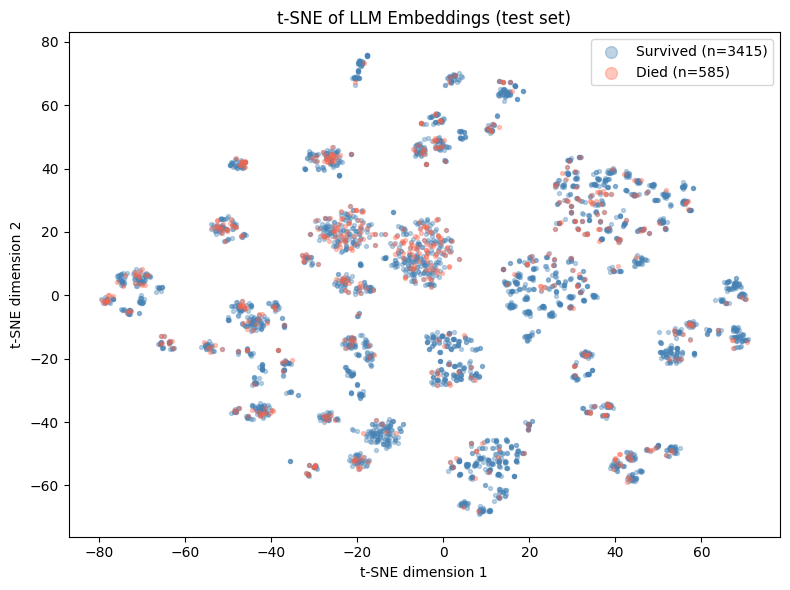

Silhouette score: 0.0027
Davies-Bouldin index: 5.8033


In [20]:
# LLM embeddings visualized like in Q3.3

test_df = pd.read_parquet("test_embeddings.parquet")
z_vis, labels = unpack_embedding_df(test_df)


print("Embeddings loadded")


# t-SNE
n = z_vis.shape[0]
perplexity = min(30, max(5, n // 10))  # keep valid for smaller subsets
tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, max_iter=1000)
z_2d = tsne.fit_transform(z_vis)

#plotting graph
print("plotting graph")
fig, ax = plt.subplots(figsize=(8, 6))
for label, color, name in zip([0, 1], ["steelblue", "tomato"], ["Survived", "Died"]):
    mask = labels == label
    ax.scatter(
        z_2d[mask, 0],
        z_2d[mask, 1],
        c=color,
        alpha=0.35,
        s=8,
        label=f"{name} (n={mask.sum()})"
    )

ax.set_title("t-SNE of LLM Embeddings (test set)")
ax.set_xlabel("t-SNE dimension 1")
ax.set_ylabel("t-SNE dimension 2")
ax.legend(markerscale=3)
plt.tight_layout()
plt.savefig("q4_2.png", dpi=300, bbox_inches="tight")
plt.show()


# Quantitative clustering metrics
sample_size = min(2000, len(labels))
sil = silhouette_score(z_vis, labels, metric="euclidean", sample_size=sample_size, random_state=42)
db = davies_bouldin_score(z_vis, labels)

print(f"Silhouette score: {sil:.4f}")
print(f"Davies-Bouldin index: {db:.4f}")

# Question 4.3

In [3]:
from tqdm.auto import tqdm


def clean_patient_matrix(group_df, feature_cols):
    """
    Build channel-first matrix [C, T] for one patient and impute missing values.
    """
    x = group_df[feature_cols].to_numpy(dtype=np.float32)  # [T, C]
    x = pd.DataFrame(x).ffill().fillna(0.0).to_numpy(dtype=np.float32) #use forward fill, and else change values to 0.0
    return x.T  # [C, T]


@torch.inference_mode()
def patient_embedding_from_group(group_df, feature_cols, pipeline, encoder, device):
    """
    One forward pass per patient:
    - channels treated as batch items (univariate series)
    - mean pool tokens per channel
    - average across channels to one patient embedding
    """
    x_ct = clean_patient_matrix(group_df, feature_cols)  # [C, T]
    context = torch.tensor(x_ct, dtype=torch.float32)    # [C, T]

    token_ids, attention_mask, _ = pipeline.tokenizer.context_input_transform(context=context)
    token_ids = token_ids.to(device)
    attention_mask = attention_mask.to(device)

    out = encoder(input_ids=token_ids, attention_mask=attention_mask)
    hidden = out.last_hidden_state  # [C, L, D]

    mask = attention_mask.unsqueeze(-1).to(hidden.dtype)  # [C, L, 1]
    channel_emb = (hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp_min(1.0)  # [C, D]

    patient_emb = channel_emb.mean(dim=0)  # [D]
    return patient_emb.detach().cpu().numpy().astype(np.float32)


def build_patient_embedding_df(df, feature_cols, pipeline, encoder, device, max_patients=None):
    rows = []

    df = df.sort_values(["RecordID", "hour"])
    if max_patients is not None:
        keep_ids = df["RecordID"].drop_duplicates().head(max_patients).tolist()
        df = df[df["RecordID"].isin(keep_ids)]

    grouped = df.groupby("RecordID", sort=False)

    for rid, g in tqdm(grouped, total=grouped.ngroups):
        y = int(g["In-hospital_death"].iloc[0])
        emb = patient_embedding_from_group(g, feature_cols, pipeline, encoder, device)
        rows.append(
            {
                "RecordID": rid,
                "In-hospital_death": y,
                "embedding": emb
            }
        )

    compact = pd.DataFrame(rows)

    # Expanded version for sklearn (emb_0, emb_1, ...)
    mat = np.vstack(compact["embedding"].to_numpy())
    emb_cols = [f"emb_{i}" for i in range(mat.shape[1])]
    expanded = pd.concat(
        [
            compact[["RecordID", "In-hospital_death"]].reset_index(drop=True),
            pd.DataFrame(mat, columns=emb_cols)
        ],
        axis=1
    )

    return compact, expanded


# 1) Load data (train + test only) (val also but not used until later)
df_train = pd.read_parquet("set_a_processed.parquet")
df_val = pd.read_parquet("set_b_processed.parquet")
df_test = pd.read_parquet("set_c_processed.parquet")

exclude_cols = {"RecordID", "hour", "In-hospital_death", "ICUType"}
feature_cols = [c for c in df_train.columns if c not in exclude_cols]
print("Number of channels:", len(feature_cols))

# Load smallest Chronos model (speed was a big issue)
model_name = "amazon/chronos-t5-tiny"
device = "cuda" if torch.cuda.is_available() else "cpu"
torch_dtype = torch.float32 if device == "cuda" else torch.float32

pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-tiny",
    device_map=device,
    dtype=torch_dtype,
)

core_model = pipeline.model.model if hasattr(pipeline.model, "model") else pipeline.model
encoder = core_model.encoder
encoder.eval()

# 3) Compute embeddings
# For a quick smoke test, set max_patients to a small number like 100
max_patients = None

train_compact, train_expanded = build_patient_embedding_df(
    df_train, feature_cols, pipeline, encoder, device, max_patients=max_patients
)
val_compact, val_expanded = build_patient_embedding_df(
    df_val, feature_cols, pipeline, encoder, device, max_patients=max_patients
)
test_compact, test_expanded = build_patient_embedding_df(
    df_test, feature_cols, pipeline, encoder, device, max_patients=max_patients
)

# 4) Save outputs
train_compact.to_parquet("train_chronos_embeddings_compact.parquet", index=False)
val_compact.to_parquet("val_chronos_embeddings_compact.parquet", index=False)
test_compact.to_parquet("test_chronos_embeddings_compact.parquet", index=False)

train_expanded.to_parquet("train_chronos_embeddings.parquet", index=False)
val_expanded.to_parquet("val_chronos_embeddings.parquet", index=False)
test_expanded.to_parquet("test_chronos_embeddings.parquet", index=False)





Number of channels: 41


100%|██████████| 4000/4000 [00:30<00:00, 132.49it/s]


In [4]:
import os
import ast
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score

def embedding_df_to_xy(df, expected_dim=None):
    # Labels
    y = df["In-hospital_death"].to_numpy(dtype=np.int64)

    # Only expanded embedding columns
    emb_cols = [c for c in df.columns if c.startswith("emb_")]
    if not emb_cols:
        raise ValueError("Expected expanded embedding columns: emb_0, emb_1, ...")

    # Keep embedding columns in numeric order
    emb_cols = sorted(emb_cols, key=lambda c: int(c.split("_")[1]))

    # Features
    X = df[emb_cols].to_numpy(dtype=np.float32)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    if expected_dim is not None and X.shape[1] != expected_dim:
        raise ValueError(f"Expected embedding dim {expected_dim}, got {X.shape[1]}")

    return X, y

# Load embeddings
train_df = pd.read_parquet("train_chronos_embeddings.parquet")
test_df  = pd.read_parquet("test_chronos_embeddings.parquet")

X_train, y_train = embedding_df_to_xy(train_df)
X_test, y_test   = embedding_df_to_xy(test_df)

# Linear probe
print("training linear probe")
probe = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        solver="lbfgs",
        random_state=42
    )
)

probe.fit(X_train, y_train)

# Test metrics
print("evaluating model")
test_prob = probe.predict_proba(X_test)[:, 1]
test_auroc = roc_auc_score(y_test, test_prob)
test_auprc = average_precision_score(y_test, test_prob)

print(f"Test AUROC: {test_auroc:.4f}")
print(f"Test AUPRC: {test_auprc:.4f}")

training linear probe
evaluating model
Test AUROC: 0.7082
Test AUPRC: 0.3108


more suitable architecture

In [9]:


#set seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

TRAIN_PATH = "set_a_processed.parquet"
VAL_PATH   = "set_b_processed.parquet"
TEST_PATH  = "set_c_processed.parquet"

# smallest Chronos
CHRONOS_MODEL = "amazon/chronos-t5-tiny"

# cache files for channel embeddings
CACHE = {
    "train_X": "train_channel_emb.npy",
    "train_y": "train_labels.npy",
    "val_X": "val_channel_emb.npy",
    "val_y": "val_labels.npy",
    "test_X": "test_channel_emb.npy",
    "test_y": "test_labels.npy",
}

BATCH_SIZE = 128
EPOCHS = 30
LR = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 6  # early stopping patience on val AUROC

device = "cuda" if torch.cuda.is_available() else "cpu"
torch_dtype = torch.bfloat16 if device == "cuda" else torch.float32



#Chronos channel embeddings

def clean_patient_matrix(group_df, feature_cols):
    # [T, C] -> fill missing -> [C, T]
    x = group_df[feature_cols].to_numpy(dtype=np.float32)
    x = pd.DataFrame(x).ffill().fillna(0.0).to_numpy(dtype=np.float32)
    return x.T  # [C, T]


@torch.inference_mode()
def channel_embeddings_for_patient(group_df, feature_cols, pipeline, encoder, device):
    """
    Returns channel embeddings for one patient: [C, D]
    """
    x_ct = clean_patient_matrix(group_df, feature_cols)
    context = torch.tensor(x_ct, dtype=torch.float32)  # [C, T]

    token_ids, attention_mask, _ = pipeline.tokenizer.context_input_transform(context=context)
    token_ids = token_ids.to(device)
    attention_mask = attention_mask.to(device)

    out = encoder(input_ids=token_ids, attention_mask=attention_mask)

    # Force fp32 before any cpu/numpy conversion to avoid bfloat16 numpy issues
    hidden = out.last_hidden_state.to(torch.float32)         # [C, L, D]
    mask = attention_mask.unsqueeze(-1).to(torch.float32)    # [C, L, 1]

    ch_emb = (hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp_min(1.0)  # [C, D]
    return ch_emb.detach().cpu().numpy().astype(np.float32)


def build_split_channel_embeddings(df, feature_cols, pipeline, encoder, device):
    df = df.sort_values(["RecordID", "hour"])
    grouped = df.groupby("RecordID", sort=False)

    X_list, y_list = [], []
    for _, g in tqdm(grouped, total=grouped.ngroups):
        y = int(g["In-hospital_death"].iloc[0])
        ch_emb = channel_embeddings_for_patient(g, feature_cols, pipeline, encoder, device)  # [C, D]
        X_list.append(ch_emb)
        y_list.append(y)

    X = np.stack(X_list).astype(np.float32)  # [N, C, D]
    y = np.asarray(y_list, dtype=np.int64)   # [N]
    return X, y


def get_or_build_embeddings():
    # load data
    df_train = pd.read_parquet(TRAIN_PATH)
    df_val   = pd.read_parquet(VAL_PATH)
    df_test  = pd.read_parquet(TEST_PATH)

    exclude = {"RecordID", "hour", "In-hospital_death", "ICUType"}
    feature_cols = [c for c in df_train.columns if c not in exclude]
    print("Number of channels:", len(feature_cols))

    # use cache if available
    if all(os.path.exists(p) for p in CACHE.values()):
        X_train = np.load(CACHE["train_X"])
        y_train = np.load(CACHE["train_y"])
        X_val   = np.load(CACHE["val_X"])
        y_val   = np.load(CACHE["val_y"])
        X_test  = np.load(CACHE["test_X"])
        y_test  = np.load(CACHE["test_y"])
        print("Loaded cached channel embeddings.")
        return X_train, y_train, X_val, y_val, X_test, y_test

    # build Chronos
    pipeline = ChronosPipeline.from_pretrained(
        CHRONOS_MODEL,
        device_map=device,
        torch_dtype=torch_dtype,
    )
    core_model = pipeline.model.model if hasattr(pipeline.model, "model") else pipeline.model
    encoder = core_model.encoder
    encoder.eval()

    X_train, y_train = build_split_channel_embeddings(df_train, feature_cols, pipeline, encoder, device)
    X_val, y_val     = build_split_channel_embeddings(df_val, feature_cols, pipeline, encoder, device)
    X_test, y_test   = build_split_channel_embeddings(df_test, feature_cols, pipeline, encoder, device)

    # save cache
    np.save(CACHE["train_X"], X_train)
    np.save(CACHE["train_y"], y_train)
    np.save(CACHE["val_X"], X_val)
    np.save(CACHE["val_y"], y_val)
    np.save(CACHE["test_X"], X_test)
    np.save(CACHE["test_y"], y_test)
    print("Saved channel-embedding cache.")

    return X_train, y_train, X_val, y_val, X_test, y_test



# Lightweight channel aggregator

class ChannelAttentionProbe(nn.Module):
    """
    Input:  [B, C, D]
    Output: mortality logit [B]
    """
    def __init__(self, emb_dim, attn_hidden=64, dropout=0.1):
        super().__init__()
        self.score_net = nn.Sequential(
            nn.Linear(emb_dim, attn_hidden),
            nn.Tanh(),
            nn.Linear(attn_hidden, 1)
        )
        self.head = nn.Sequential(
            nn.LayerNorm(emb_dim),
            nn.Dropout(dropout),
            nn.Linear(emb_dim, 1)
        )

    def forward(self, x):
        # x: [B, C, D]
        scores = self.score_net(x).squeeze(-1)      # [B, C]
        alpha = torch.softmax(scores, dim=1)        # [B, C]
        pooled = (alpha.unsqueeze(-1) * x).sum(1)   # [B, D]
        logits = self.head(pooled).squeeze(-1)      # [B]
        return logits, alpha


@torch.no_grad()
def predict_proba(model, X_np, batch_size=256):
    model.eval()
    ds = TensorDataset(torch.from_numpy(X_np))
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False)

    probs = []
    for (xb,) in dl:
        xb = xb.to(device)
        logits, _ = model(xb)
        p = torch.sigmoid(logits).cpu().numpy()
        probs.append(p)
    return np.concatenate(probs)


def train_probe(model, X_train, y_train, X_val, y_val):
    X_train_t = torch.from_numpy(X_train)
    y_train_t = torch.from_numpy(y_train.astype(np.float32))

    train_ds = TensorDataset(X_train_t, y_train_t)
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

    # class imbalance handling
    pos = float((y_train == 1).sum())
    neg = float((y_train == 0).sum())
    pos_weight = torch.tensor([neg / max(pos, 1.0)], dtype=torch.float32, device=device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    best_state = None
    best_val_auc = -np.inf
    wait = 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss = 0.0
        n_seen = 0

        for xb, yb in train_dl:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits, _ = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)
            n_seen += xb.size(0)

        train_loss = running_loss / max(n_seen, 1)

        val_prob = predict_proba(model, X_val, batch_size=256)
        val_auc = roc_auc_score(y_val, val_prob)
        val_ap = average_precision_score(y_val, val_prob)

        print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_AUROC={val_auc:.4f} | val_AUPRC={val_ap:.4f}")

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= PATIENCE:
                print("Early stopping.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model


def run_baseline_mean_pool_lr(X_train, y_train, X_test, y_test):
    # baseline: non-parametric mean over channels + linear probe
    Xtr = X_train.mean(axis=1)  # [N, D]
    Xte = X_test.mean(axis=1)

    clf = LogisticRegression(max_iter=2000, class_weight="balanced")
    clf.fit(Xtr, y_train)
    prob = clf.predict_proba(Xte)[:, 1]
    auc = roc_auc_score(y_test, prob)
    ap = average_precision_score(y_test, prob)
    return auc, ap



X_train, y_train, X_val, y_val, X_test, y_test = get_or_build_embeddings()
print("Shapes:")
print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

emb_dim = X_train.shape[-1]

# baseline for comparison
b_auc, b_ap = run_baseline_mean_pool_lr(X_train, y_train, X_test, y_test)
print(f"\nBaseline mean-pool + LR | Test AUROC={b_auc:.4f} | Test AUPRC={b_ap:.4f}")

# learned channel aggregation probe
model = ChannelAttentionProbe(emb_dim=emb_dim, attn_hidden=64, dropout=0.1).to(device)
model = train_probe(model, X_train, y_train, X_val, y_val)

test_prob = predict_proba(model, X_test, batch_size=256)
test_auc = roc_auc_score(y_test, test_prob)
test_ap = average_precision_score(y_test, test_prob)

print(f"\nLearned channel-attention probe | Test AUROC={test_auc:.4f} | Test AUPRC={test_ap:.4f}")


Number of channels: 41
Loaded cached channel embeddings.
Shapes:
Train: (4000, 41, 256) (4000,)
Val:   (4000, 41, 256) (4000,)
Test:  (4000, 41, 256) (4000,)

Baseline mean-pool + LR | Test AUROC=0.6751 | Test AUPRC=0.2569
Epoch 01 | train_loss=1.1855 | val_AUROC=0.6538 | val_AUPRC=0.2372
Epoch 02 | train_loss=1.1730 | val_AUROC=0.6678 | val_AUPRC=0.2478
Epoch 03 | train_loss=1.1534 | val_AUROC=0.6776 | val_AUPRC=0.2547
Epoch 04 | train_loss=1.1411 | val_AUROC=0.6854 | val_AUPRC=0.2601
Epoch 05 | train_loss=1.1281 | val_AUROC=0.6927 | val_AUPRC=0.2657
Epoch 06 | train_loss=1.1198 | val_AUROC=0.7009 | val_AUPRC=0.2743
Epoch 07 | train_loss=1.1219 | val_AUROC=0.7089 | val_AUPRC=0.2826
Epoch 08 | train_loss=1.1091 | val_AUROC=0.7152 | val_AUPRC=0.2909
Epoch 09 | train_loss=1.1131 | val_AUROC=0.7193 | val_AUPRC=0.2989
Epoch 10 | train_loss=1.1107 | val_AUROC=0.7215 | val_AUPRC=0.2973
Epoch 11 | train_loss=1.0844 | val_AUROC=0.7229 | val_AUPRC=0.3017
Epoch 12 | train_loss=1.0792 | val_AUROC